# Glucose × HRV Analysis

Pulls continuous glucose (CGM) and overnight HRV for one study subject from BigQuery, **interpolates HRV onto the dense glucose timeline** (`queries/glucose_hrv_interpolated.sql`), and explores the relationship.

> **Read HRV with care:** Garmin measures HRV only during sleep, so daytime glucose rows get an HRV value *interpolated across the overnight gaps* — it's a bridge between nights, not a real waking measurement.

**Setup:** `pip install -r requirements.txt` and `gcloud auth application-default login` (see README).

## 1. Setup

In [25]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT = 'digitaltwin-499202'
USER    = 'christian'   # study subject: 'vincent', 'kevin', or 'christian'

client = bigquery.Client(project=PROJECT)
print(f'BigQuery client ready — project={PROJECT}, subject={USER}')

BigQuery client ready — project=digitaltwin-499202, subject=christian


## 2. Load glucose + interpolated HRV
The query lives in `queries/glucose_hrv_interpolated.sql` and is parameterized by `@user`.

In [26]:
sql = Path('queries/glucose_hrv_interpolated.sql').read_text().replace('PROJECT_PLACEHOLDER', PROJECT)
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ScalarQueryParameter('user', 'STRING', USER)])
df = client.query(sql, job_config=job_config).to_dataframe()
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts').reset_index(drop=True)
print(f"{len(df):,} glucose rows | {df['ts'].min()} -> {df['ts'].max()}")
df.head()

1,493 glucose rows | 2026-07-09 14:02:17+00:00 -> 2026-07-15 17:30:09+00:00


,user_id,ts,glucose_mg_dl,prev_hrv_val,prev_hrv_ts,next_hrv_val,next_hrv_ts,hrv_interpolated
0,christian,2026-07-09 14:02:17+00:00,92.0,61.0,2026-07-09 14:01:35+00:00,61.0,2026-07-09 14:06:35+00:00,61.000000
1,christian,2026-07-09 14:07:16+00:00,96.0,61.0,2026-07-09 14:06:35+00:00,65.0,2026-07-09 14:11:35+00:00,61.546667
2,christian,2026-07-09 14:12:17+00:00,97.0,65.0,2026-07-09 14:11:35+00:00,65.0,2026-07-09 14:16:35+00:00,65.000000
3,christian,2026-07-09 14:17:17+00:00,98.0,65.0,2026-07-09 14:16:35+00:00,85.0,2026-07-09 14:21:35+00:00,67.800000
4,christian,2026-07-09 14:22:17+00:00,100.0,85.0,2026-07-09 14:21:35+00:00,86.0,2026-07-09 14:26:35+00:00,85.140000


## 3. Summary statistics

In [27]:
df[['glucose_mg_dl', 'hrv_interpolated']].describe().round(1)

,glucose_mg_dl,hrv_interpolated
count,1493.0,1493.0
mean,93.2,67.1
std,10.7,11.0
min,63.0,37.9
25%,86.0,54.9
50%,92.0,66.7
75%,98.0,75.0
max,147.0,109.6


## 4. Glucose over time

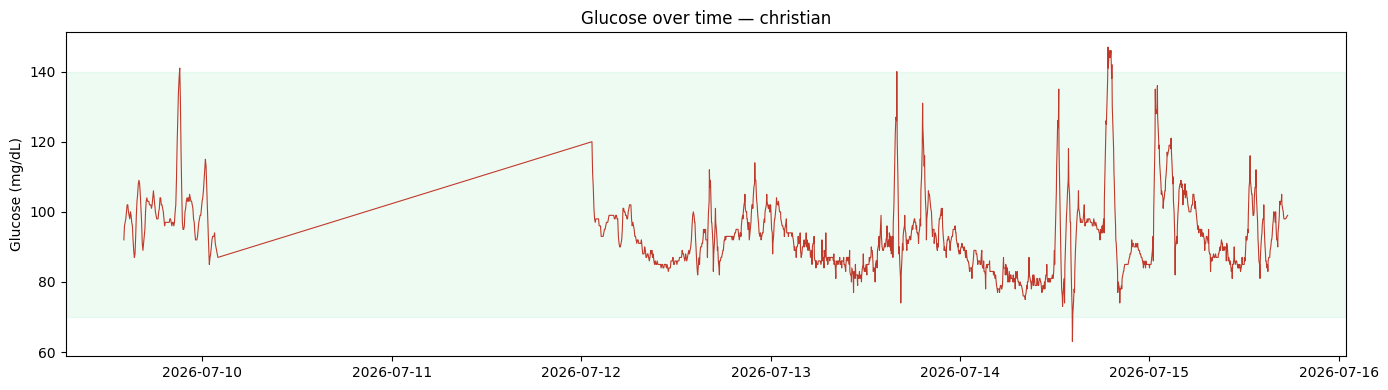

In [28]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['ts'], df['glucose_mg_dl'], lw=0.8, color='#c0392b')
ax.axhspan(70, 140, color='#2ecc71', alpha=0.08)  # rough in-range band
ax.set_title(f'Glucose over time — {USER}')
ax.set_ylabel('Glucose (mg/dL)')
plt.tight_layout(); plt.show()

## 5. Glucose vs interpolated HRV (dual axis)

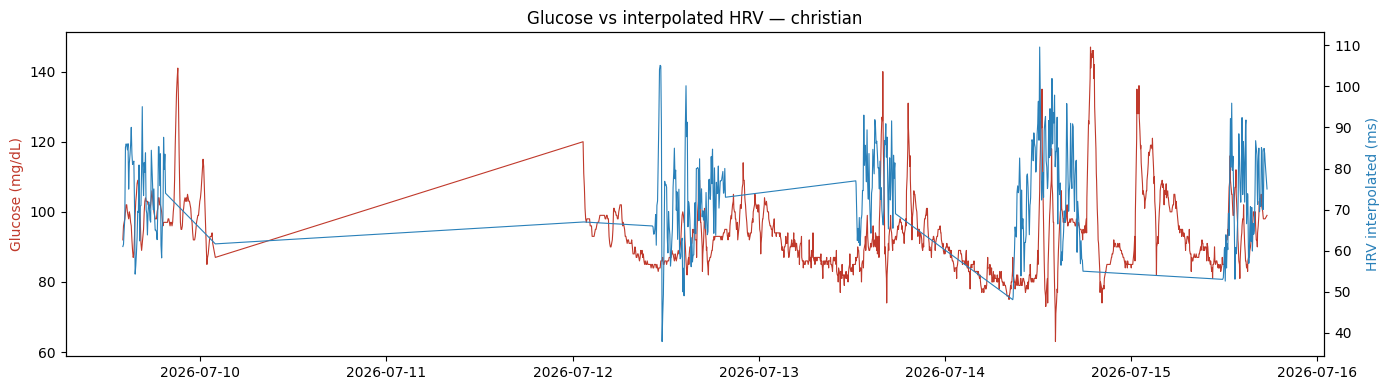

In [29]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(df['ts'], df['glucose_mg_dl'], lw=0.8, color='#c0392b')
ax1.set_ylabel('Glucose (mg/dL)', color='#c0392b')
ax2 = ax1.twinx()
ax2.plot(df['ts'], df['hrv_interpolated'], lw=0.8, color='#2980b9')
ax2.set_ylabel('HRV interpolated (ms)', color='#2980b9')
ax1.set_title(f'Glucose vs interpolated HRV — {USER}')
plt.tight_layout(); plt.show()

## 6. Relationship
Scatter + Pearson correlation. (Correlation here is dominated by the overnight interpolation, so treat it as exploratory.)

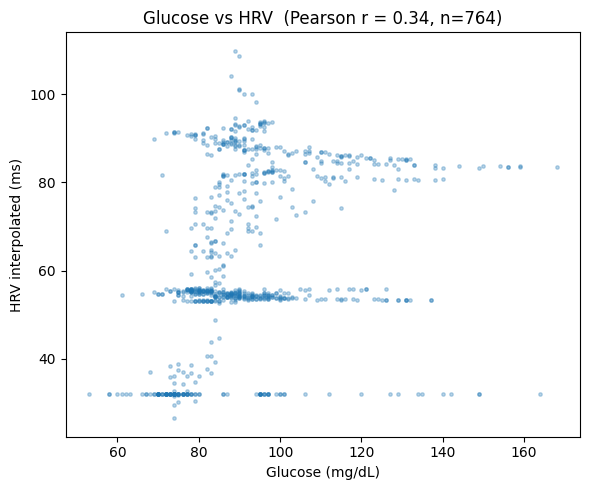

Pearson r = 0.335  (n=764)


In [13]:
sub = df.dropna(subset=['glucose_mg_dl', 'hrv_interpolated'])
r = sub['glucose_mg_dl'].corr(sub['hrv_interpolated'])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sub['glucose_mg_dl'], sub['hrv_interpolated'], s=6, alpha=0.3)
ax.set_xlabel('Glucose (mg/dL)'); ax.set_ylabel('HRV interpolated (ms)')
ax.set_title(f'Glucose vs HRV  (Pearson r = {r:.2f}, n={len(sub):,})')
plt.tight_layout(); plt.show()
print(f'Pearson r = {r:.3f}  (n={len(sub):,})')